In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime
import os
import json
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
from alplakes import parse_alplakes_3d_timeserie_from_directory, get_3d_profile_from_api, parse_json_3d_profile_to_df, parse_alplakes_1d_from_directory
from utils import save_json, open_json

### Parameters

In [3]:
lake_name = "geneva"
sta_name = 'geneva_lexplore'

year = 2024
model = f'1000m_{year}_diffKzTx100'

In [4]:
var_to_plot = 'THETA'

In [20]:
data_folder = r"D:\01-Geneva calibration\geneva_1000m_2024\crop_results"

## Import cropped netcdf MITgcm results

In [21]:
mitgcm_paths = [os.path.join(data_folder, r"lexplore_depth_time.nc")]

mitgcm_labels = ["MITgcm"]

In [22]:
xr_mitgcm = []
for i in range(len(mitgcm_paths)):
    xr_mitgcm.append(xr.open_dataset(mitgcm_paths[i]))

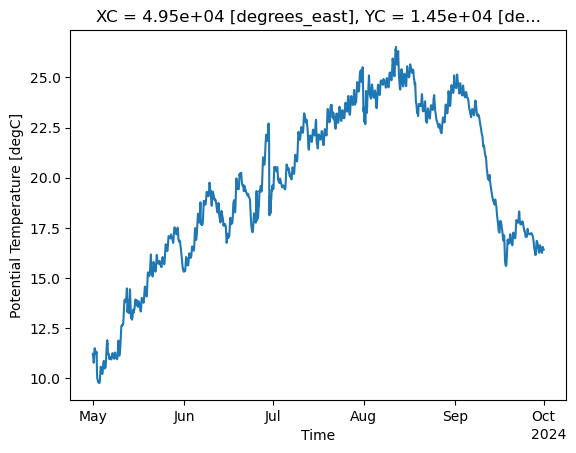

In [23]:
xr_mitgcm[0]['THETA'].isel(Z=0).plot()
plt.show()

## Import measure

In [24]:
start_date = pd.to_datetime(xr_mitgcm[0]['time'].values[0]).to_pydatetime()  #datetime(2024, 1, 1, 0, 0, 0)
end_date = pd.to_datetime(xr_mitgcm[0]['time'].values[-1]).to_pydatetime() #datetime(2025, 1, 1, 0, 0, 0)

In [25]:
xr_measure = xr.open_dataset(f'./data/measures/geneva/idronaut/{year}.nc')

## Import KPP profile

In [26]:
date_plot_profil = datetime(year,1, 1,1,0,0)

In [27]:
xr_kpp = xr.open_dataset(os.path.join(data_folder, r"lexplore_kpp.nc"))

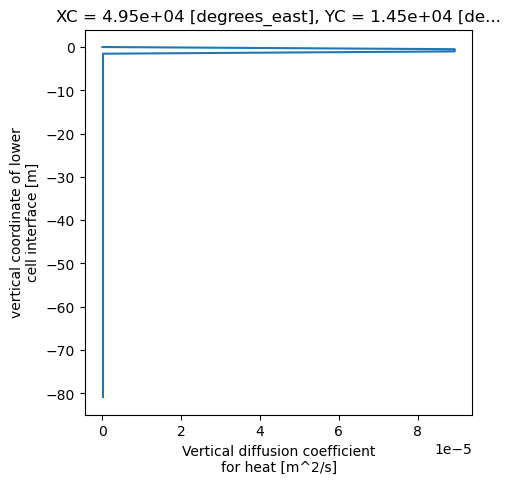

In [28]:
plt.figure(figsize=(5,5))
xr_mitgcm[0].KPPdiffT.sel(time=date_plot_profil, method='nearest').isel(Zl=range(60)).plot(y='Zl')
plt.show()

In [29]:
xr_mitgcm[0].KPPdiffT.sel(time=date_plot_profil, method='nearest').values

array([0.0000000e+00, 8.9425812e-05, 8.9425717e-05, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e-07,
       1.4000000e-07, 1.4000000e-07, 1.4000000e-07, 1.4000000e

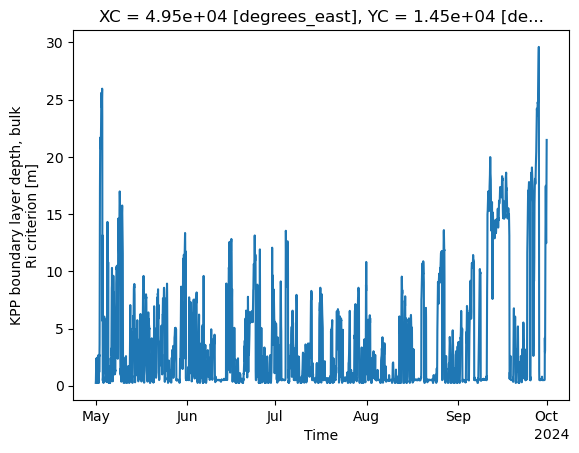

In [30]:
plt.figure()
xr_kpp.KPPhbl.plot()

## Define secchi depth

In [23]:
secchi_depths = [6.8,6.5,6.3,6,5,4.5,4,4,4,4,6,6]

## Plot

In [26]:
def plot_profile(j):
    plt.close()
    fig, ax = plt.subplots(1,3,figsize=(10, 7))
    
    date_plot_profil = pd.Timestamp(xr_mitgcm[0].time.values[j]).to_pydatetime()
    
    meas_profile = xr_measure['temp'].sel(time=date_plot_profil, method='nearest')
    ax[0].plot(meas_profile.values, meas_profile.depth.values, label=f'Idronaut measure', color='r')
    
    for i in range(len(xr_mitgcm)):
        profile_mitgcm = xr_mitgcm[i][var_to_plot].sel(time=date_plot_profil, method='nearest')
        profile_mitgcm.where(profile_mitgcm != 0, np.nan).plot(y='Z', label=f'{mitgcm_labels[i]}', ax=ax[0])
    
    hbl = float(-xr_kpp.KPPhbl.sel(time=date_plot_profil, method='nearest').values)
    ax[0].axhline(y=hbl, color='black', linestyle='--', label=f'hbl= {round(hbl,2)}m')
    
    secchi = secchi_depths[date_plot_profil.month-1]
    ax[0].axhline(y=-secchi, color='blue', linestyle='--', label=f'Secchi= {round(secchi,2)}m')
    
    ax[0].set_title(f"{date_plot_profil}")
    ax[0].grid(True, which='both', linestyle='-', linewidth=0.5)
    ax[0].set_ylabel('Depth (m)')
    ax[0].set_ylim(bottom=-100, top=1)
    ax[0].set_xlim(left=6, right=28)
    ax[0].set_xlabel('Temperature (°C)')
    ax[0].xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax[0].legend()
    
    xr_mitgcm[0].KPPdiffT.sel(time=date_plot_profil, method='nearest').plot(y='Zl', ax=ax[1], label='KPPdiffT')
    ax[1].set_title("")
    ax[1].grid(True, which='both', linestyle='-', linewidth=0.5)
    ax[1].set_ylim(bottom=-100, top=1)
    ax[1].set_xlim(left=xr_mitgcm[0].KPPdiffT.min(), right=xr_mitgcm[0].KPPdiffT.max())
    ax[1].set_ylabel('')
    ax[1].xaxis.set_major_locator(ticker.MultipleLocator(0.01))
    ax[1].legend()
    
    speed = xr_mitgcm[0].UVEL**2+xr_mitgcm[0].VVEL**2
    speed.sel(time=date_plot_profil, method='nearest').plot(y='Z', ax=ax[2], label='u**2 + v**2')
    ax[2].set_title("")
    ax[2].grid(True, which='both', linestyle='-', linewidth=0.5)
    ax[2].set_ylim(bottom=-100, top=1)
    ax[2].set_xlim(left=speed.min(), right=speed.max())
    ax[2].set_xlabel('u^2 + v^2 [m^2/s^2]')
    ax[2].set_ylabel('')
    ax[2].xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax[2].legend()
    
    plt.show()
    #plt.savefig(rf"output_plots\video_profiles\{lake_name}\{model}_profile_{j}.png")

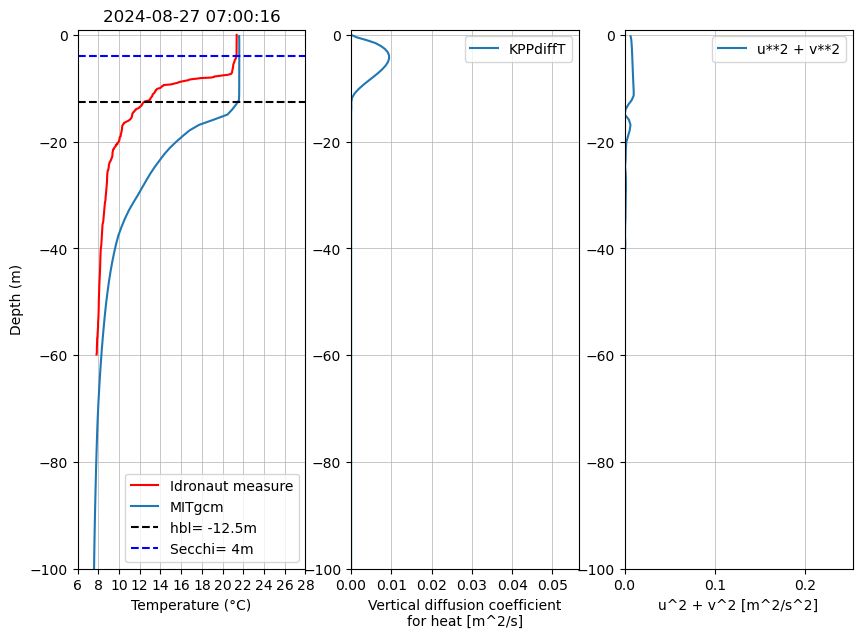

In [25]:
plot_profile(2838)

In [27]:
%matplotlib inline

for j in range(len(xr_mitgcm[0].time.values)):
    plot_profile(j)

## KPP analysis

In [24]:
u = xr_mitgcm[0].UVEL.sel(time=date_plot_profil, method='nearest').isel(Z=range(60))
v = xr_mitgcm[0].VVEL.sel(time=date_plot_profil, method='nearest').isel(Z=range(60))
delta_u = u - u.isel(Z=0)
delta_v = v - v.isel(Z=0)

In [25]:
plt.figure(figsize=(5,5))
(delta_u**2+delta_v**2).plot(y='Z')
plt.show()

<IPython.core.display.Javascript object>

In [26]:
temp = xr_mitgcm[0].THETA.sel(time=date_plot_profil, method='nearest').isel(Z=range(60)) + 273.15
delta_temp = temp - temp.isel(Z=0)

In [27]:
z = xr_mitgcm[0].Z.isel(Z=range(60))
delta_z = z - z.isel(Z=0)

In [28]:
Rib = 9.81 * (delta_temp / temp.isel(Z=0)) * delta_z / (delta_u**2+delta_v**2)

In [29]:
plt.figure(figsize=(5,5))
Rib.plot(y='Z')
plt.show()

<IPython.core.display.Javascript object>